In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px 
import math
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from statsmodels.stats.outliers_influence import variance_inflation_factor
import category_encoders as ce


In [2]:
df = pd.read_csv('Real_life.csv')
df.head()

,Brand,Price,Body,Mileage,EngineV,Engine Type,Registration,Year,Model
0,BMW,4200.0,sedan,277,2.0,Petrol,yes,1991,320
1,Mercedes-Benz,7900.0,van,427,2.9,Diesel,yes,1999,Sprinter 212
2,Mercedes-Benz,13300.0,sedan,358,5.0,Gas,yes,2003,S 500
3,Audi,23000.0,crossover,240,4.2,Petrol,yes,2007,Q7
4,Toyota,18300.0,crossover,120,2.0,Petrol,yes,2011,Rav 4


# Exploration of DataSet

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4345 entries, 0 to 4344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         4345 non-null   object 
 1   Price         4173 non-null   float64
 2   Body          4345 non-null   object 
 3   Mileage       4345 non-null   int64  
 4   EngineV       4195 non-null   float64
 5   Engine Type   4345 non-null   object 
 6   Registration  4345 non-null   object 
 7   Year          4345 non-null   int64  
 8   Model         4345 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 305.6+ KB


In [4]:
np.round(df.describe(),2)

,Price,Mileage,EngineV,Year
count,4173.00,4345.00,4195.00,4345.00
mean,19418.75,161.24,2.79,2006.55
std,25584.24,105.71,5.07,6.72
min,600.00,0.00,0.60,1969.00
25%,6999.00,86.00,1.80,2003.00
50%,11500.00,155.00,2.20,2008.00
75%,21700.00,230.00,3.00,2012.00
max,300000.00,980.00,99.99,2016.00


In [5]:
df.isnull().sum()

Brand             0
Price           172
Body              0
Mileage           0
EngineV         150
Engine Type       0
Registration      0
Year              0
Model             0
dtype: int64

In [6]:
df.dropna(axis=0, inplace=True)

In [7]:
target_enc = ce.TargetEncoder(cols=['Brand'])
df['Encoded'] = target_enc.fit_transform(df['Brand'], df['Price'])

In [8]:
# Looking for outliers in the price columns
px.scatter(df,'Price',size='Price', title="Outliers of Price column")

In [9]:
# Remove 2% of the outliers of the column Price
q = df['Price'].quantile(0.98)
df = df[df['Price']<q]
px.scatter(df,'Price', size='Price', title="Price column without outliers")

In [10]:
# Looking for outliers in the price columns
px.scatter(df,'Mileage', size='Mileage', title="Outliers of the Mileage column")

In [11]:
# Remove 1% of the outliers of the column Mileage
q = df['Mileage'].quantile(0.99)
df = df[df['Mileage']<q]
px.scatter(df,'Mileage', size='Mileage', title="Mileage column without outliers")

In [12]:
# Looking for outliers in the EngineV column
px.scatter(df,'EngineV', size='EngineV', title="Outliers of the EngineV column")

In [13]:
# Removing wrong data because cars can not has more than 6.5 lts
df = df[df['EngineV']<6.5]
px.scatter(df,'EngineV', size='EngineV', title="EngineV column without outliers")

In [14]:
# Looking for outliers in the year column 
px.scatter(df, 'Year', size='Year', title="Outliers of the year column")

In [15]:
# Removing outliers of the Year column because older cars are more pricy than current cars
q = df['Year'].quantile(0.01)
df = df[df['Year']>q]
px.scatter(df,'Year', size='Year', title="Year column without outliers")

<Axes: title={'center': 'Correlation between variables'}>

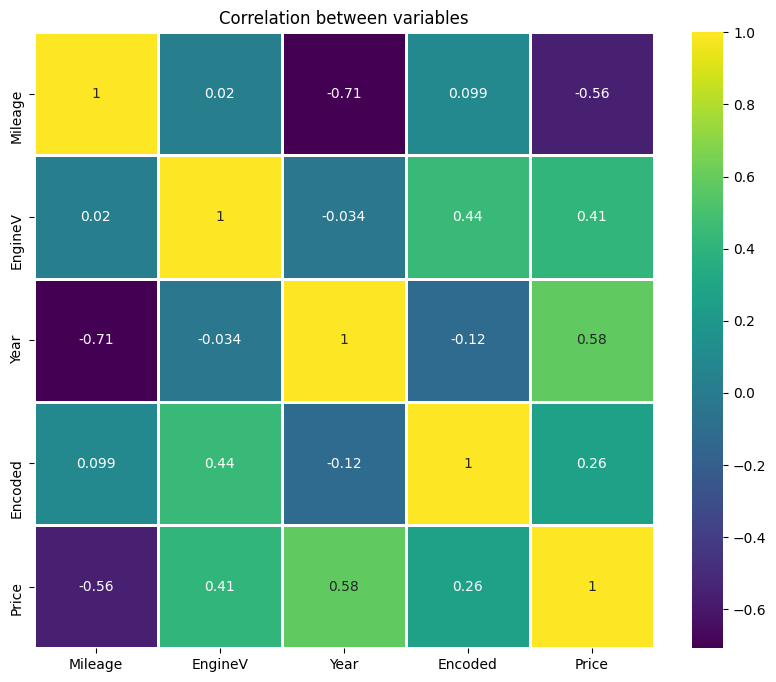

In [16]:
# correlation of values column in the datafra
corr = df[['Mileage', 'EngineV','Year','Encoded','Price']]

plt.figure(figsize=(10,8))
plt.title("Correlation between variables")
sns.heatmap(corr.corr(), linecolor="white", linewidths=2, annot=True, cmap="viridis")

# Machine Learning Model

In [18]:
X = df[['EngineV','Year','Encoded']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(f'X_train.shape: {X_train.shape}')
print(f'X_test.shape: {X_test.shape}')
print(f'y_train.shape: {y_train.shape}')
print(f'y_test.shape: {y_test.shape}')

X_train.shape: (3060, 3)
X_test.shape: (766, 3)
y_train.shape: (3060,)
y_test.shape: (766,)


In [19]:
LR = LinearRegression()
LR.fit(X_train, y_train)

print(f'Intercept: {LR.intercept_}')
print(f'Coefficients: {LR.coef_}')
print(f'R Squared: {LR.score(X,y)}')

Intercept: -3375302.448946794
Coefficients: [6.06953653e+03 1.67948755e+03 3.90691432e-01]
R Squared: 0.5514778329028975


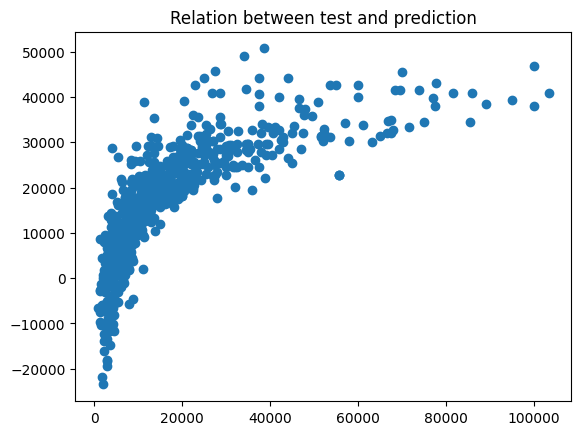

In [20]:
y_prediction = LR.predict(X_test)
plt.title("Relation between test and prediction")
plt.scatter(y_test,y_prediction)


In [21]:
print('Mean Absolute Error:',mean_absolute_error(y_test, y_prediction))
print('Mean Squared Error:',mean_squared_error(y_test, y_prediction))
print('Root Mean Squared Error:',math.sqrt(mean_squared_error(y_test, y_prediction)))

Mean Absolute Error: 7323.674448292106
Mean Squared Error: 119000331.62207036
Root Mean Squared Error: 10908.727314497799


c:\Users\ddrodriguez\Documents\Python\conda\Lib\site-packages\seaborn\distributions.py:2551: FutureWarning:

`distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).



<Axes: xlabel='Price', ylabel='Density'>

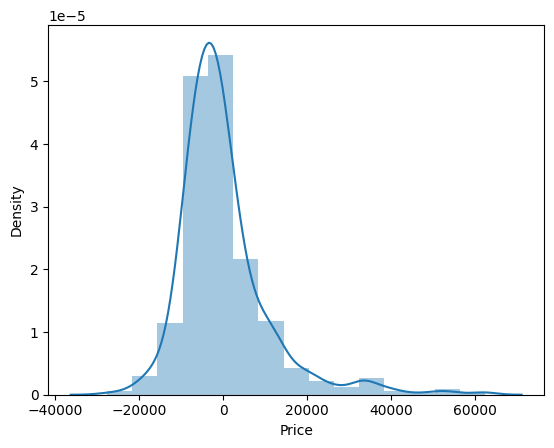

In [22]:
residuals = y_test - y_prediction
sns.distplot(residuals, bins=15)

In [23]:
# Features = [['EngineV','Year','Encoded]]
# features = np.array([[277,2.0,22746]])
# LR.predict(features)

In [24]:
# Linear Regression with al dataframe
features = np.array(df[['EngineV','Year','Encoded']])

df['Prediction'] = LR.predict(features)
df['Wastes'] = df['Price'] - df['Prediction'] 

c:\Users\ddrodriguez\Documents\Python\conda\Lib\site-packages\sklearn\base.py:464: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



Text(0, 0.5, 'Predictions')

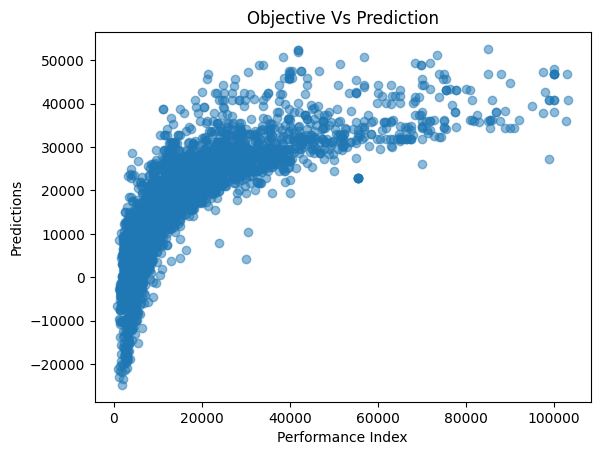

In [25]:
plt.scatter(df['Price'], df['Prediction'], alpha=0.5)
plt.title("Objective Vs Prediction")
plt.xlabel("Performance Index")
plt.ylabel("Predictions")